# Exploratory Analysis

In [2]:
#Importing packages and setting parameters for initial analysis
import geopandas as gpd
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../src')
from ntl_functions import plot_NASA_NTL, filter_dataset_by_bounding_box



In [3]:
#Load Somaliland Boundary Shapefile
somaliland_shp_berbera = gpd.read_file("../data/Combined_Datasets/Somaliland_with_berbera/somaliland_with_berbera.shp")

In [4]:
SL_berbera = xr.open_dataset("../data/NTL_Data_A4/141225_SL_Berbera_VNP46A4_EY_2012_24.nc")

#Monthly Data.
SL_month = xr.open_dataset("../data/NTL_Data_A4/141225_SL_VNP46A3_EM_2012_2017.nc")
SL_qual = xr.open_dataset("../data/NTL_Data_A4/141225_Qual_SL_VNP46A3_EM_2012_2017.nc")
SL_num = xr.open_dataset("../data/NTL_Data_A4/141225_Num_SL_VNP46A3_EM_2012_2017.nc")



Exploring the extent and values of the VNP46A4 Data for Somaliland.

In [5]:
print("SL Berbera", list(SL_berbera.data_vars))

SL Berbera ['NearNadir_Composite_Snow_Free']


In [6]:
print(SL_berbera.coords)
print(SL_berbera.rio.resolution())
print(SL_berbera.rio.bounds())

Coordinates:
  * time     (time) datetime64[ns] 96B 2012-01-01 2013-01-01 ... 2023-01-01
  * y        (y) float64 7kB 11.51 11.51 11.5 11.5 ... 8.015 8.01 8.006 8.002
  * x        (x) float64 12kB 42.69 42.69 42.69 42.7 ... 49.06 49.07 49.07 49.08
(0.004166666666666666, -0.004166717529296876)
(42.68345540364584, 7.999975585937501, 49.079288736979166, 11.512518463134768)


In [7]:
#Showing the total number of pixels in Somaliland, the number of pixels with light detected each year, and the total radiance each year. 
non_zero_pixels = []
total_pixels = []
radiance_data = []
for year in range(2012, 2024):
    total_pixels.append(round((SL_berbera["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01")).count().item(), 1))
    non_zero_pixels.append(round((SL_berbera["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01") > 0).sum().item(), 1))
    radiance_data.append(round((SL_berbera["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01")).sum().item(), 1))

df = pd.DataFrame({
    "year": list(range(2012, 2024)),
    "total_pixels": total_pixels,
    "non_zero_pixels": non_zero_pixels,
    "radiance_data": radiance_data
})
print(df)

    year  total_pixels  non_zero_pixels  radiance_data
0   2012        804375              569         1724.6
1   2013        804375              581         1787.3
2   2014        804375              668         1956.1
3   2015        804375              757         2165.4
4   2016        804375              760         2328.6
5   2017        804375              887         2740.7
6   2018        804375             1050         3516.3
7   2019        804375             1139         4322.6
8   2020        804375             1318         5641.5
9   2021        804375             1760         7800.5
10  2022        804375             2426         9731.8
11  2023        804375             2570        10788.8


In [8]:
df.corr()

,year,total_pixels,non_zero_pixels,radiance_data
year,1.000000,NaN,0.916003,0.921607
total_pixels,NaN,NaN,NaN,NaN
non_zero_pixels,0.916003,NaN,1.000000,0.993910
radiance_data,0.921607,NaN,0.993910,1.000000


In [9]:
growth_rates = df.set_index("year").pct_change().multiply(100).round(1)
growth_rates
growth_rates.corr()

,total_pixels,non_zero_pixels,radiance_data
total_pixels,NaN,NaN,NaN
non_zero_pixels,NaN,1.000000,0.731431
radiance_data,NaN,0.731431,1.000000


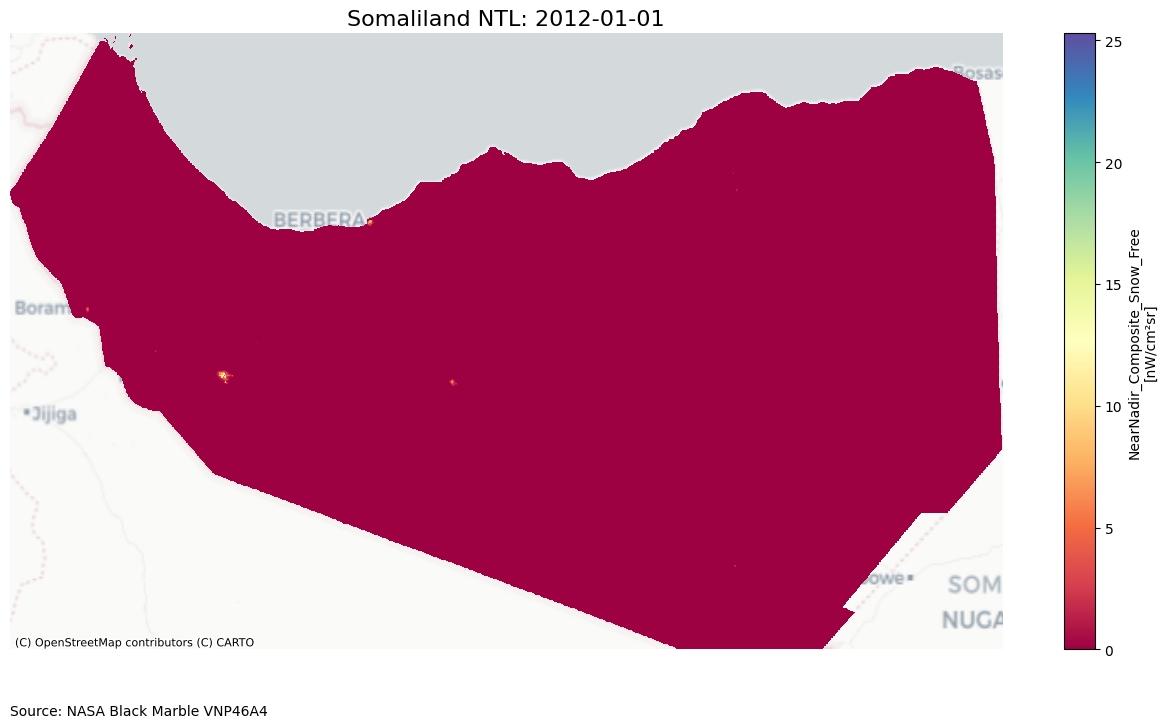

In [10]:
plot_NASA_NTL(SL_berbera, somaliland_shp_berbera, date = "2012-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              robust = False)

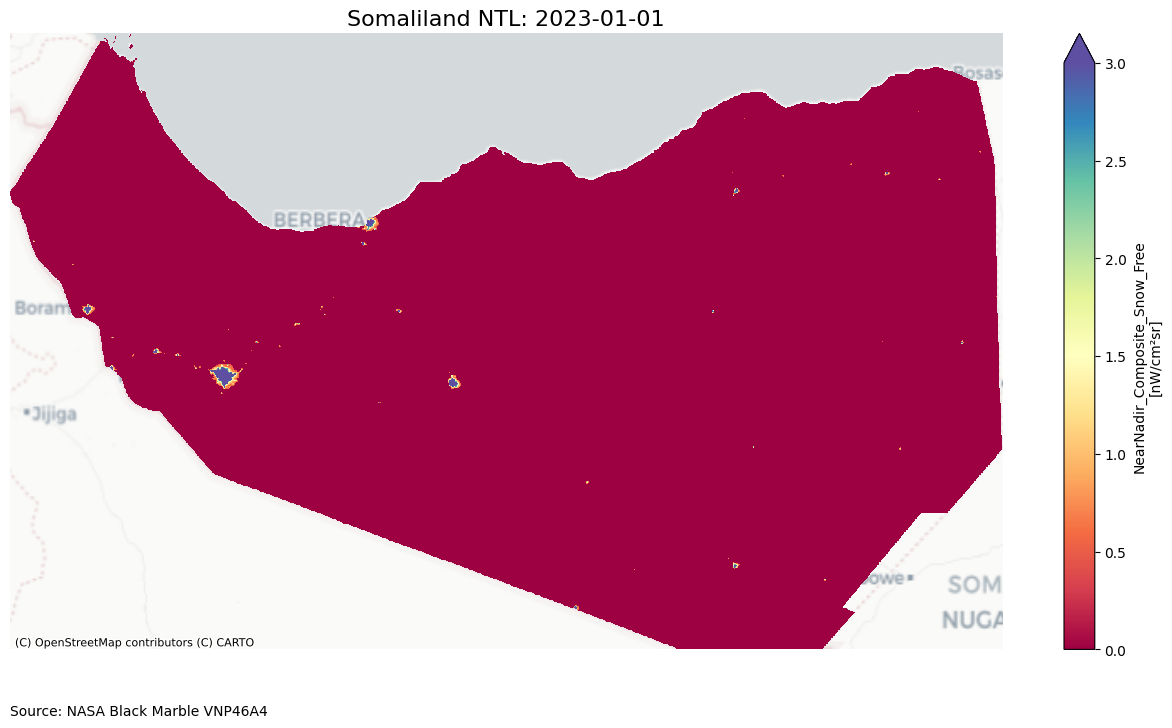

In [11]:
plot_NASA_NTL(SL_berbera, somaliland_shp_berbera, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              robust = False, vmin=0, vmax=3)

Demonstrating why Annual Data has been used rather than monthly data.

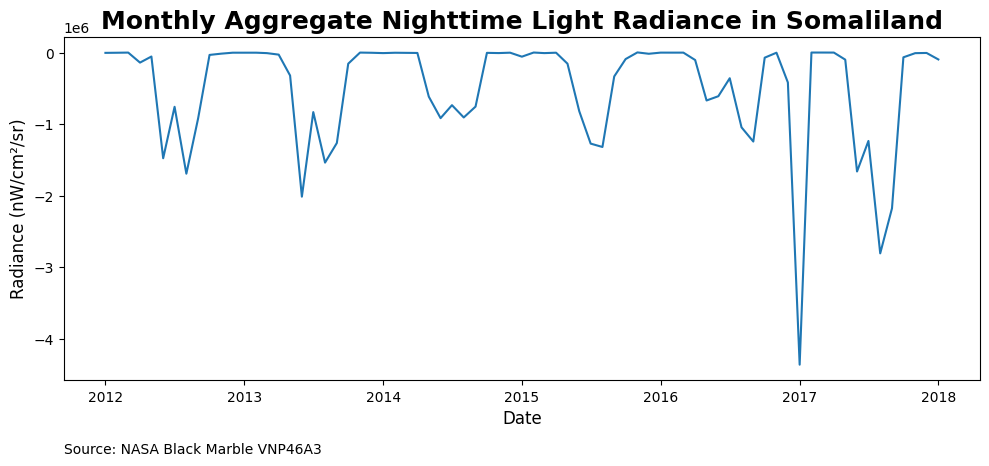

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
SL_month["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]).plot(ax=ax)

ax.set_title(
    "Monthly Aggregate Nighttime Light Radiance in Somaliland", fontsize=18, weight="bold"
)

ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Radiance (nW/cm²/sr)", fontsize=12)
ax.text(
    0,
    -0.2,
    "Source: NASA Black Marble VNP46A3",
    ha="left",
    va="center",
    transform=ax.transAxes,
    fontsize=10,
    color="black",
    weight="normal",
)

fig.tight_layout()
plt.show()

In [13]:
#Examining min values shows that fill values of -999.9 are present in the monthly data. 
print(SL_month["NearNadir_Composite_Snow_Free"].min())
print(SL_month["NearNadir_Composite_Snow_Free"].max())

<xarray.DataArray 'NearNadir_Composite_Snow_Free' ()> Size: 8B
array(-999.90002441)
Attributes:
    units:         nW/cm²sr
    long_name:     NearNadir_Composite_Snow_Free
    grid_mapping:  spatial_ref
<xarray.DataArray 'NearNadir_Composite_Snow_Free' ()> Size: 8B
array(37.45820999)
Attributes:
    units:         nW/cm²sr
    long_name:     NearNadir_Composite_Snow_Free
    grid_mapping:  spatial_ref


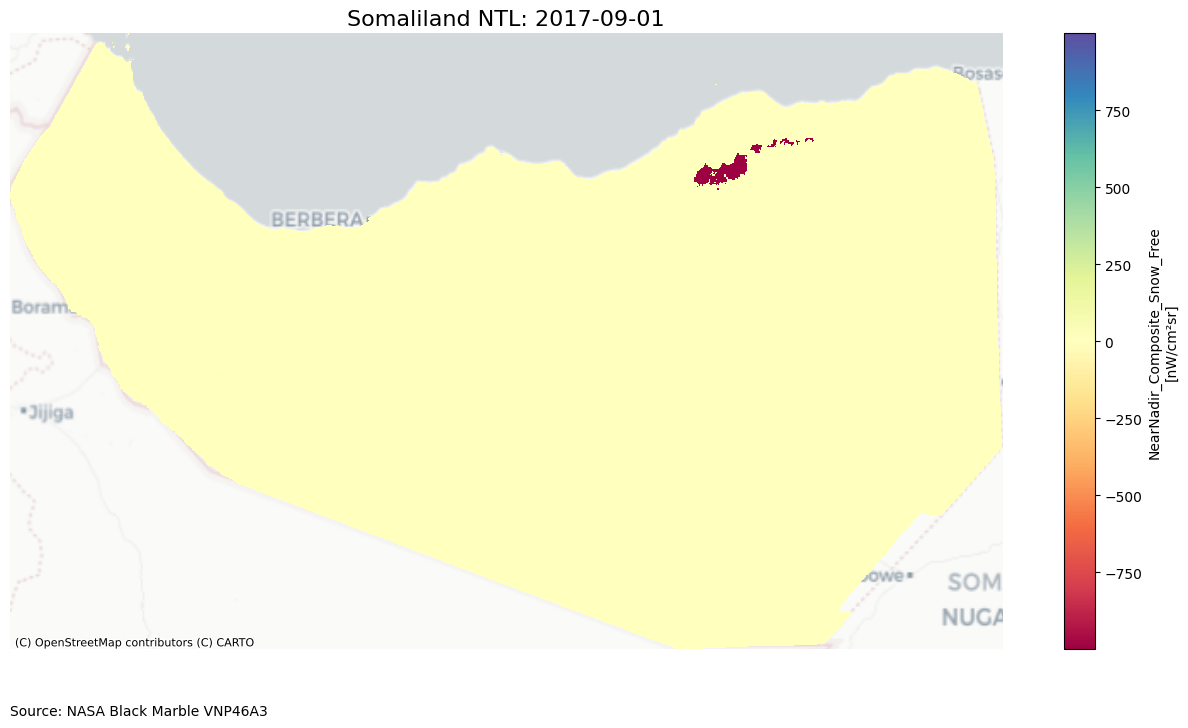

In [14]:
plot_NASA_NTL(SL_month, somaliland_shp_berbera, date = "2017-09-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              source="VNP46A3",
              robust = False)

In [15]:
#A large amount of fill values are present in the monthly data. Calculating the number of fill values per month.
month_total_pixels = []
month_filled = []
for i in SL_month.time.to_index():
    month_total_pixels.append(round((SL_month["NearNadir_Composite_Snow_Free"].sel(time=i)).count().item(), 1))
    month_filled.append((SL_month["NearNadir_Composite_Snow_Free"].sel(time=i) == SL_month["NearNadir_Composite_Snow_Free"].min()).sum().item())

df = pd.DataFrame({
    "time": list(SL_month.time.values),
    "month_total_pixels": month_total_pixels,
    "month_filled": month_filled,
})

df

,time,month_total_pixels,month_filled
0,2012-01-01,807889,2
1,2012-02-01,807889,1
2,2012-03-01,807889,0
3,2012-04-01,807889,139
4,2012-05-01,807889,57
...,...,...,...
68,2017-09-01,807889,2179
69,2017-10-01,807889,66
70,2017-11-01,807889,11
71,2017-12-01,807889,5


In [16]:
#Even removing the fill values of -999.9, there is a massive variation in total radiance in the monthly data.
clean_SL_month = xr.where(
    SL_month < -999, 
    0, # Assigning 0 for filled values (value of -999.9).
    SL_month 
)


month_total_pixels = []
month_non_zero_pixels = []
month_radiance = []
for i in SL_month.time.to_index():
    month_total_pixels.append(round((clean_SL_month["NearNadir_Composite_Snow_Free"].sel(time=i)).count().item(), 1))
    month_non_zero_pixels.append(round((clean_SL_month["NearNadir_Composite_Snow_Free"].sel(time=i) > 0).sum().item(), 1))
    month_radiance.append(round((clean_SL_month["NearNadir_Composite_Snow_Free"].sel(time=i)).sum().item(), 1))


df = pd.DataFrame({
    "time": list(SL_month.time.values),
    "month_total_pixels": month_total_pixels,
    "month_non_zero_pixels": month_non_zero_pixels,
    "month_radiance": month_radiance,
})

df


,time,month_total_pixels,month_non_zero_pixels,month_radiance
0,2012-01-01,807889,638,1465.9
1,2012-02-01,807889,1183,2163.4
2,2012-03-01,807889,2937,3345.7
3,2012-04-01,807889,1623,2239.8
4,2012-05-01,807889,5880,5204.3
...,...,...,...,...
68,2017-09-01,807889,1556,2911.4
69,2017-10-01,807889,1323,3223.9
70,2017-11-01,807889,6134,6286.8
71,2017-12-01,807889,932,3115.2


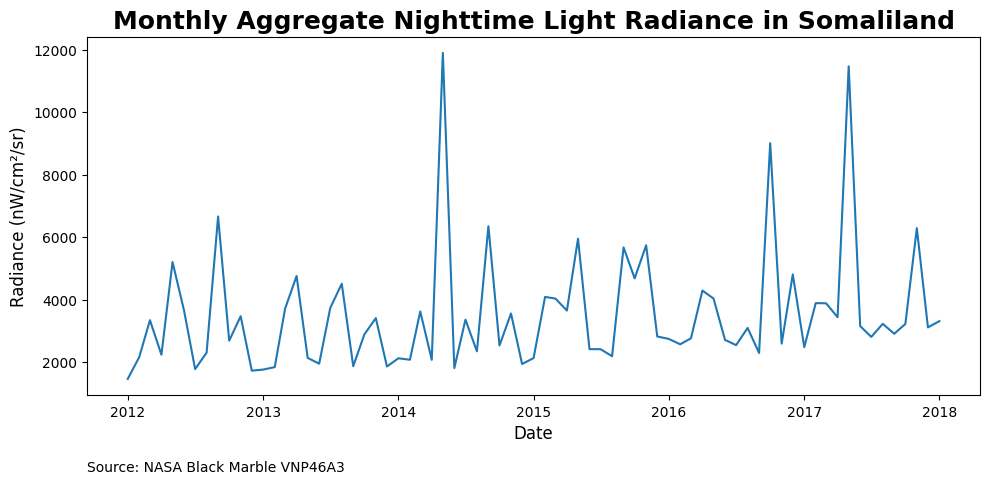

In [17]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 5))

# Plot NTL radiance
clean_SL_month["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]).plot(ax=ax)

ax.set_title(
    "Monthly Aggregate Nighttime Light Radiance in Somaliland", fontsize=18, weight="bold"
)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Radiance (nW/cm²/sr)", fontsize=12)
ax.text(
    0,
    -0.2,
    "Source: NASA Black Marble VNP46A3",
    ha="left",
    va="center",
    transform=ax.transAxes,
    fontsize=10,
    color="black",
    weight="normal",
)

fig.tight_layout()
plt.show()

In [18]:
#Selecting the peak months with radiance above 11,000 nW/cm²/sr to understand drivers of variation. 
clean_SL_month.sel(time=clean_SL_month["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]) > 11000).time.to_index()

DatetimeIndex(['2014-05-01', '2017-05-01'], dtype='datetime64[ns]', name='time', freq=None)

The graphs below show how there are a large number pixels with much higher values in the Sanaag region. 

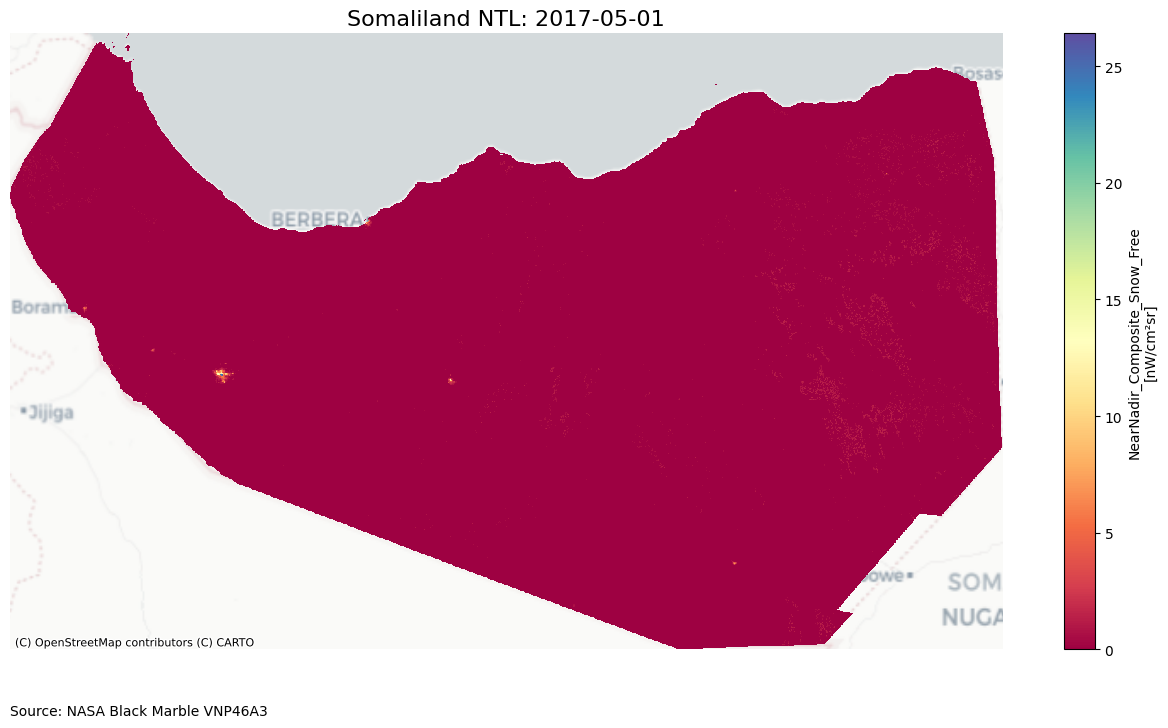

In [19]:
plot_NASA_NTL(clean_SL_month, somaliland_shp_berbera, date = "2017-05-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              source="VNP46A3",
              robust = False)

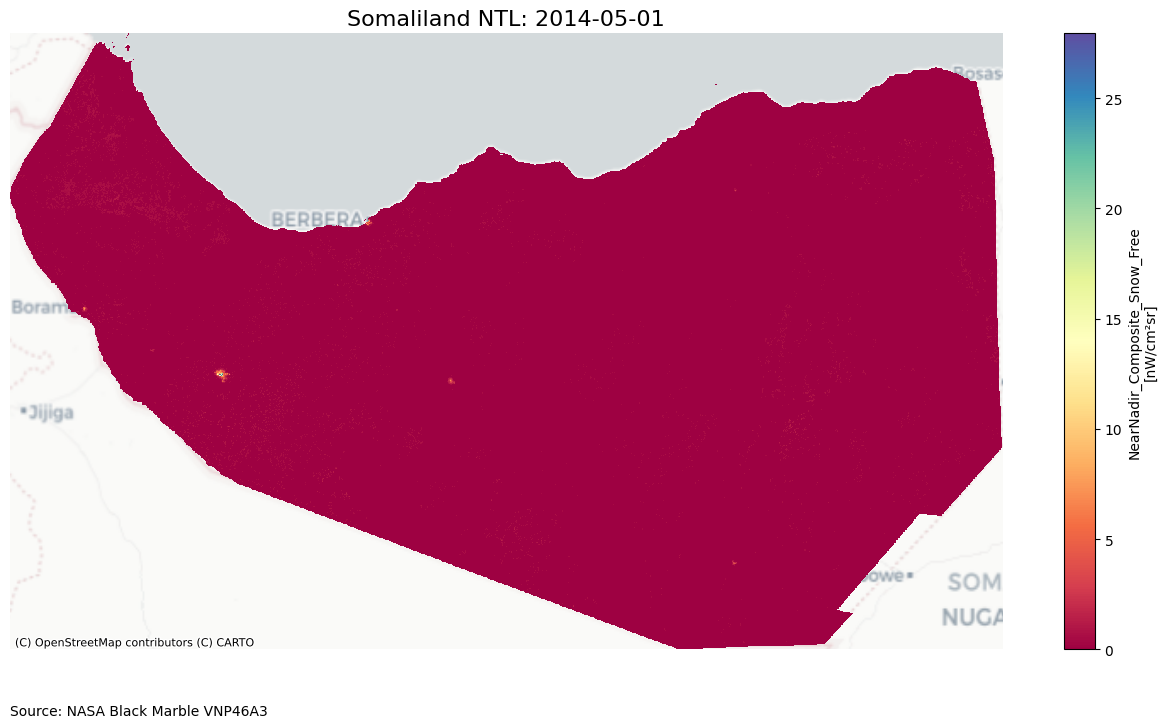

In [20]:
plot_NASA_NTL(clean_SL_month, somaliland_shp_berbera, date = "2014-05-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              source="VNP46A3",
              robust = False)

The graph below shows the quality of the observations per pixel. This potentially explains the variation. 
We also show the number of observations per pixel which demonstrates why there is lower quality in the Sanaag area. 

00 Good-quality The number of observations used for the
composite is larger than 3
01 Poor-quality The number of observations used for the
composite is less than or equal to 3
02 Gap filled Gap filled NTL based on historical data
255 Fill value Fill value


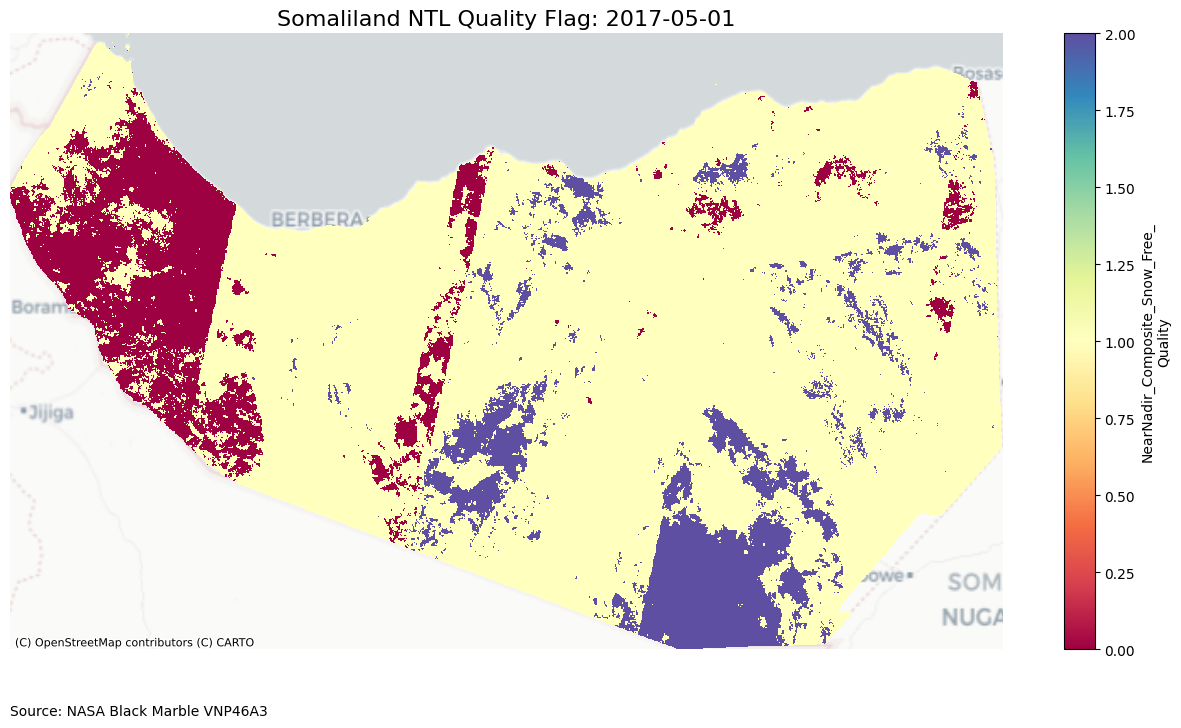

In [21]:
plot_NASA_NTL(SL_qual, somaliland_shp_berbera, date = "2017-05-01", 
              variable = "NearNadir_Composite_Snow_Free_Quality", robust=False, source="VNP46A3", title_prefix="Somaliland NTL Quality Flag")

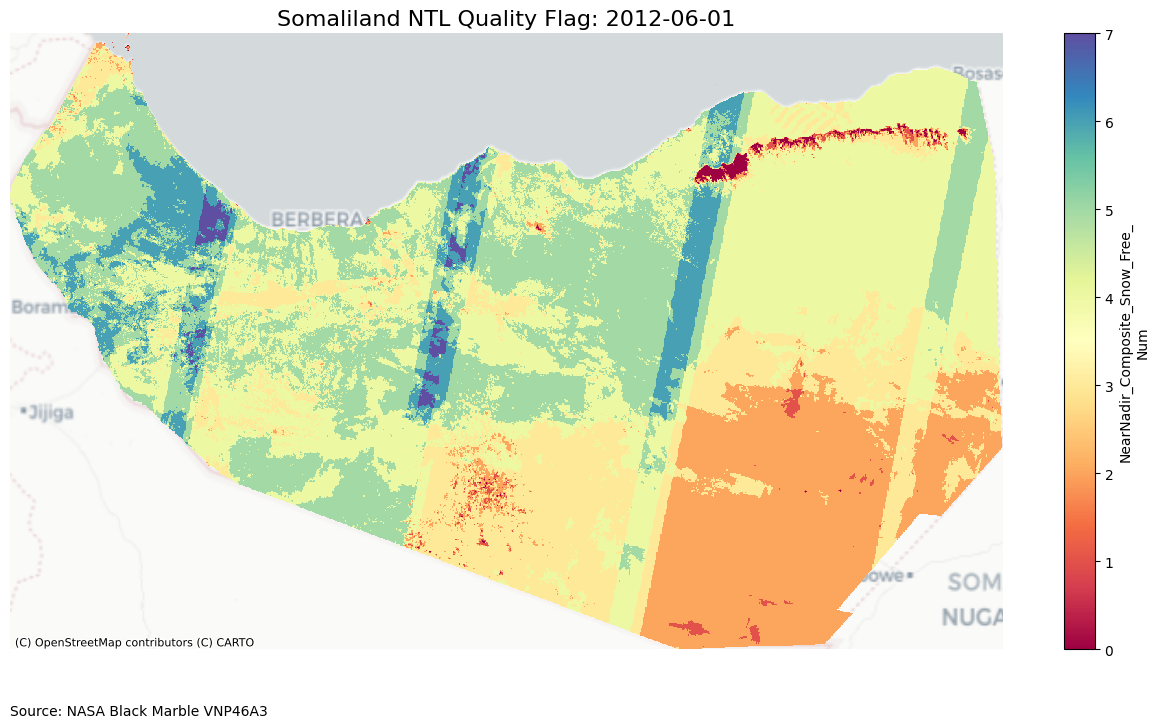

In [22]:
plot_NASA_NTL(SL_num, somaliland_shp_berbera, date = "2012-06-01", 
              variable = "NearNadir_Composite_Snow_Free_Num", robust=False, source="VNP46A3", title_prefix="Somaliland NTL Quality Flag")


In [23]:
values2012 = SL_berbera["NearNadir_Composite_Snow_Free"].sel(time="2012-01-01").values.flatten()
values2012 = values2012[~np.isnan(values2012)]
values2012 = values2012[values2012 > 0]

values2023 = SL_berbera["NearNadir_Composite_Snow_Free"].sel(time="2023-01-01").values.flatten()
values2023 = values2023[~np.isnan(values2023)]
values2023 = values2023[values2023 > 0]

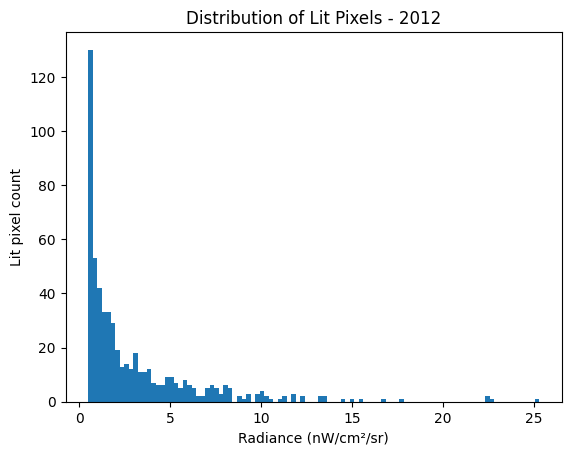

In [24]:
plt.hist(values2012, bins=100)
plt.xlabel("Radiance (nW/cm²/sr)")
plt.ylabel("Lit pixel count")
plt.title("Distribution of Lit Pixels - 2012")
plt.show()

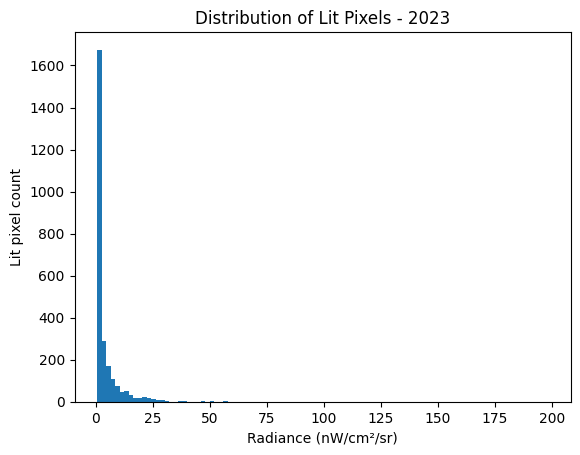

In [25]:
plt.hist(values2023, bins=100)
plt.xlabel("Radiance (nW/cm²/sr)")
plt.ylabel("Lit pixel count")
plt.title("Distribution of Lit Pixels - 2023")
plt.show()

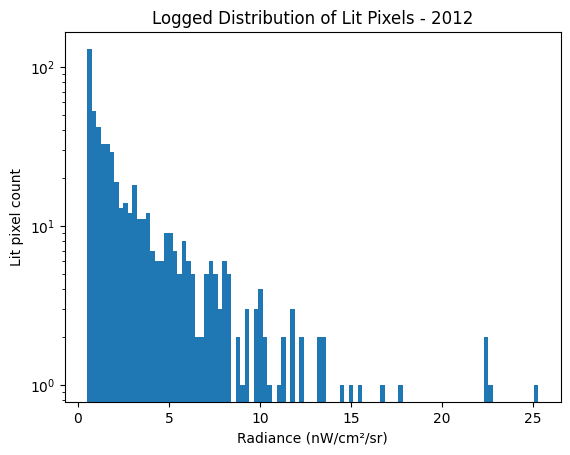

In [30]:
plt.hist(values2012, bins=100, log=True)
plt.xlabel("Radiance (nW/cm²/sr)")
plt.ylabel("Lit pixel count")
plt.title("Logged Distribution of Lit Pixels - 2012")
plt.show()

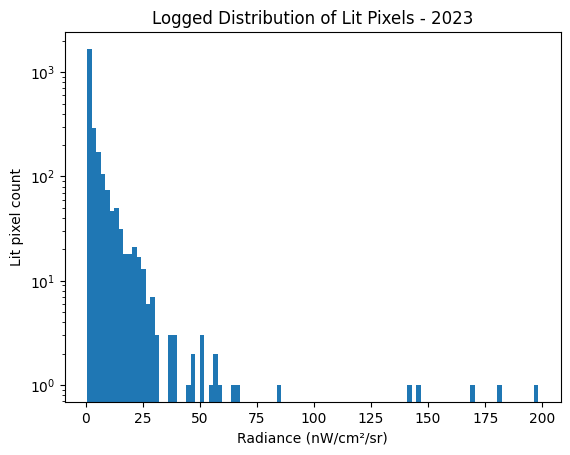

In [29]:
plt.hist(values2023, bins=100, log=True)
plt.xlabel("Radiance (nW/cm²/sr)")
plt.ylabel("Lit pixel count")
plt.title("Logged Distribution of Lit Pixels - 2023")
plt.show()

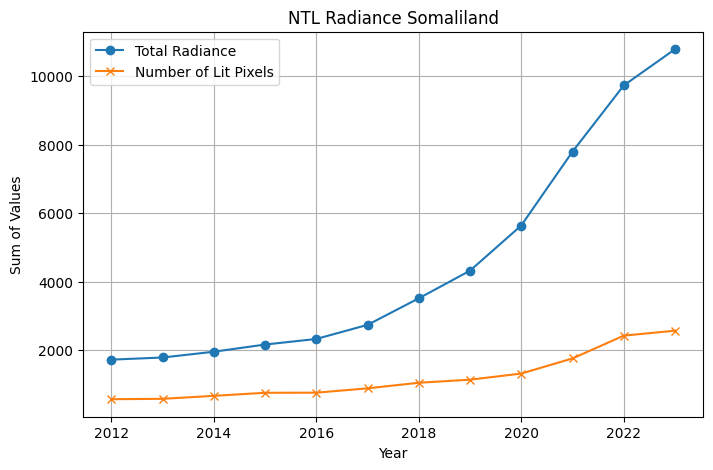

In [27]:
plt.figure(figsize=(8,5))
plt.plot(SL_berbera["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]).time.to_index(), SL_berbera["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]).values, marker="o")
plt.plot(SL_berbera["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]).time.to_index(), (SL_berbera["NearNadir_Composite_Snow_Free"] > 0).sum(dim=["x", "y"]).values, marker="x")
plt.title("NTL Radiance Somaliland")
plt.xlabel("Year")
plt.ylabel("Sum of Values")
plt.legend(["Total Radiance", "Number of Lit Pixels"])
plt.grid(True)
plt.show()